Generating trajectories for Snowdrift Game with Direct Reciprocity
Parameters: b = 1.1, α = 0.1, 100 initial conditions



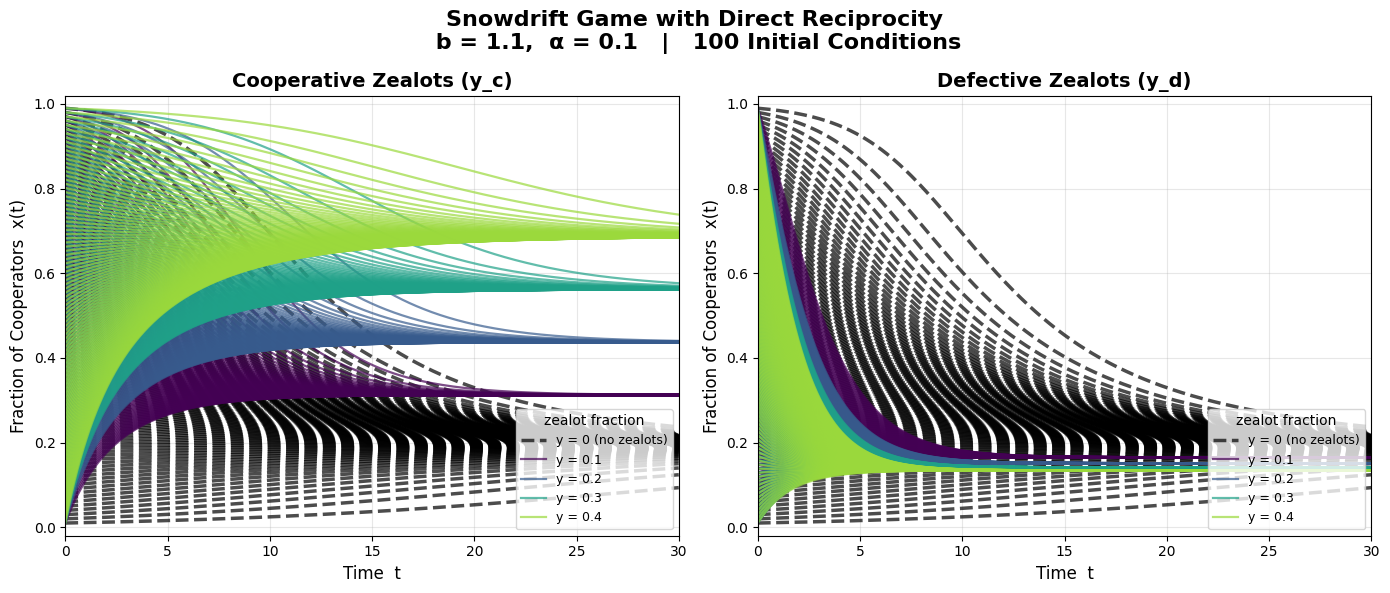

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# Snowdrift + Direct Reciprocity — b=1.1, α=0.1, 100 initial conditions
# =====================================================================

b = 1.1
alpha = 0.1
GAME_NAME = "Snowdrift Game with Direct Reciprocity"

zealot_values = [0.0, 0.1, 0.2, 0.3, 0.4]
initial_conditions = np.linspace(0.01, 0.99, 100)   # 100 initial conditions

tspan = (0, 30)
t = np.linspace(0, 30, 600)

colors = ['k'] + list(plt.cm.viridis(np.linspace(0, 0.85, len(zealot_values)-1)))
styles = ['--'] + ['-'] * (len(zealot_values)-1)
widths = [2.5] + [1.6] * (len(zealot_values)-1)


# ====================== REPLICATOR EQUATIONS ======================
def no_zealots_rhs(t, x, b, alpha):
    x = x[0]
    R = (b - 0.5) / (1 - alpha)
    dx = x * (1 - x) * ((b - 1) + x * (R - 2*b + 1))
    return [dx]

def coop_rhs(t, x, b, alpha, yc):
    x = x[0]
    R = (b - 0.5) / (1 - alpha)
    num = (1 - x) * ((x + yc) * R + (b - 1) - x * (2*b - 1))
    den = (x + yc) * R + (1 - x) * (2*b - 1)
    return [num / den] if abs(den) > 1e-12 else [0.0]

def defect_rhs(t, x, b, alpha, yd):
    x = x[0]
    R = (b - 0.5) / (1 - alpha)
    num = (1 - x) * x * R + (1 - x + yd) * ((b - 1) - x * (2*b - 1))
    den = x * R + (1 - x + yd) * (2*b - 1)
    return [num / den] if abs(den) > 1e-12 else [0.0]


# =========================== PLOTTING ===========================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

print(f"Generating trajectories for {GAME_NAME}")
print(f"Parameters: b = {b}, α = {alpha}, 100 initial conditions\n")

for k, y in enumerate(zealot_values):
    lbl = "y = 0 (no zealots)" if y == 0 else f"y = {y}"
    
    # Left Panel: Cooperative Zealots
    for x0 in initial_conditions:
        if y == 0.0:
            sol = solve_ivp(no_zealots_rhs, tspan, [x0], args=(b, alpha),
                            t_eval=t, method='LSODA', rtol=1e-8, atol=1e-10)
        else:
            sol = solve_ivp(coop_rhs, tspan, [x0], args=(b, alpha, y),
                            t_eval=t, method='LSODA', rtol=1e-8, atol=1e-10)
        ax[0].plot(sol.t, sol.y[0], color=colors[k], ls=styles[k], 
                   lw=widths[k], alpha=0.7, label=lbl if x0 == initial_conditions[0] else "")

    # Right Panel: Defective Zealots
    for x0 in initial_conditions:
        if y == 0.0:
            sol = solve_ivp(no_zealots_rhs, tspan, [x0], args=(b, alpha),
                            t_eval=t, method='LSODA', rtol=1e-8, atol=1e-10)
        else:
            sol = solve_ivp(defect_rhs, tspan, [x0], args=(b, alpha, y),
                            t_eval=t, method='LSODA', rtol=1e-8, atol=1e-10)
        ax[1].plot(sol.t, sol.y[0], color=colors[k], ls=styles[k], 
                   lw=widths[k], alpha=0.7, label=lbl if x0 == initial_conditions[0] else "")


# ====================== FORMATTING ======================
ax[0].set_title("Cooperative Zealots (y_c)", fontsize=14, fontweight='bold')
ax[1].set_title("Defective Zealots (y_d)", fontsize=14, fontweight='bold')

for a in ax:
    a.set_xlim(0, 30)
    a.set_ylim(-0.02, 1.02)
    a.grid(True, alpha=0.3)
    a.set_xlabel("Time  t", fontsize=12)
    a.set_ylabel("Fraction of Cooperators  x(t)", fontsize=12)
    a.legend(fontsize=9, title="zealot fraction", loc="lower right")

fig.suptitle(f"{GAME_NAME}\n b = {b},  α = {alpha}   |   100 Initial Conditions",
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

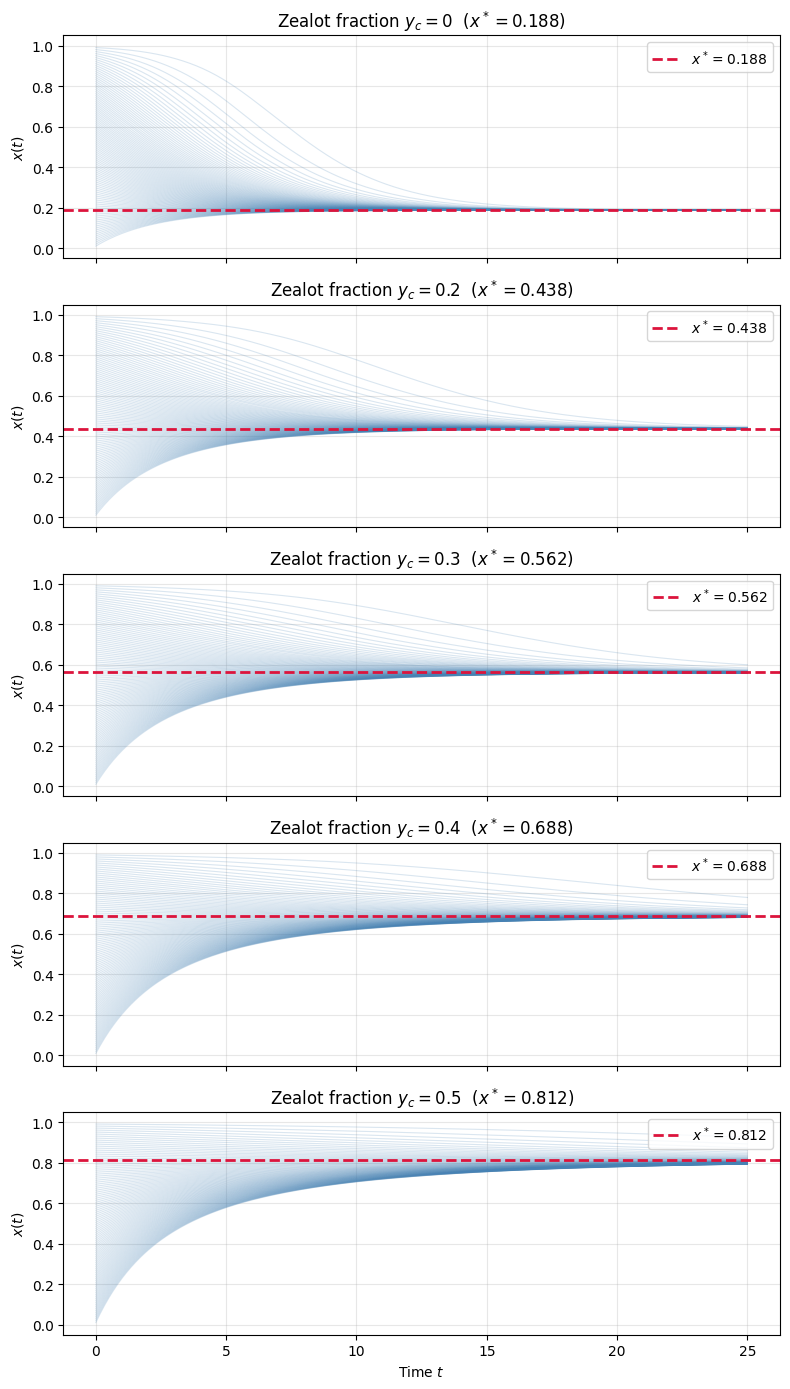

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
b = 1.1
alpha = 0.1
R = (b - 0.5) / (1 - alpha)          # ~0.6667
yc_vals = [0, 0.2, 0.3, 0.4, 0.5]
x0_vals = np.linspace(0.01, 0.99, 100)
t_span = (0, 25)
t_eval = np.linspace(0, 25, 300)

def dxdt(t, x, yc):
    B = (x + yc) * R + (b - 1) - x * (2*b - 1)
    D = (x + yc) * R + (1 - x) * (2*b - 1)
    return (1 - x) * B / D

fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True)

for ax, yc in zip(axes, yc_vals):
    x_star = 1.25 * yc + 0.1875
    
    # Loop over 100 ICs
    for x_init in x0_vals:
        sol = solve_ivp(lambda t, x: dxdt(t, x, yc),
                        t_span, [x_init], t_eval=t_eval, method='RK45')
        ax.plot(sol.t, sol.y[0], color='steelblue', alpha=0.2, lw=0.8)
    
    ax.axhline(x_star, color='crimson', ls='--', lw=2,
               label=f"$x^* = {x_star:.3f}$")
    ax.set_title(f"Zealot fraction $y_c = {yc}$  ($x^* = {x_star:.3f}$)")
    ax.set_ylabel("$x(t)$")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel("Time $t$")
plt.tight_layout()
plt.show()

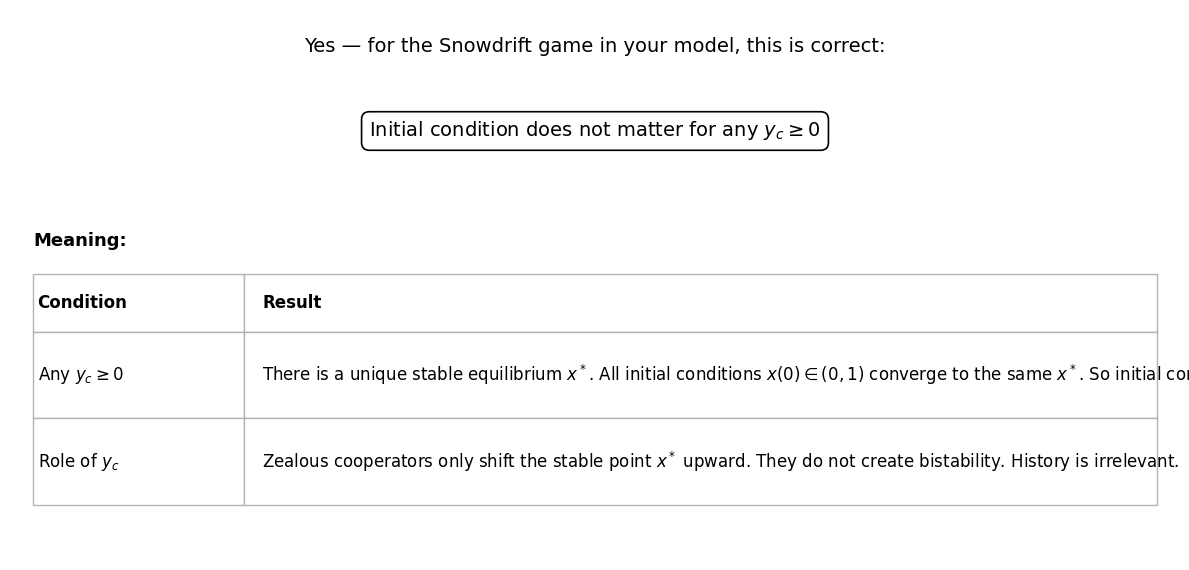

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.axis("off")

# Title
ax.text(
    0.5, 0.95,
    "Yes — for the Snowdrift game in your model, this is correct:",
    ha="center", va="top", fontsize=14
)

# Boxed condition
box_style = dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1.2)

ax.text(
    0.5, 0.78,
    r"Initial condition does not matter for any $y_c \geq 0$",
    ha="center", va="center", fontsize=14, bbox=box_style
)

# Meaning label
ax.text(0.02, 0.58, "Meaning:", fontsize=13, fontweight="bold", va="center")

# Table data
columns = ["Condition", "Result"]
cell_text = [
    [
        r"Any $y_c \geq 0$",
        r"There is a unique stable equilibrium $x^*$. All initial conditions "
        r"$x(0)\in(0,1)$ converge to the same $x^*$. So initial condition does not matter."
    ],
    [
        r"Role of $y_c$",
        r"Zealous cooperators only shift the stable point $x^*$ upward. "
        r"They do not create bistability. History is irrelevant."
    ],
]

table = ax.table(
    cellText=cell_text,
    colLabels=columns,
    cellLoc="left",
    colLoc="left",
    bbox=[0.02, 0.10, 0.96, 0.42]
)

table.auto_set_font_size(False)
table.set_fontsize(12)

# Style header and cells
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.7")
    cell.set_linewidth(1.0)
    cell.PAD = 0.02

    if row == 0:
        cell.set_text_props(weight="bold", fontsize=12)
        cell.set_facecolor("white")
        cell.set_height(0.12)
    else:
        cell.set_facecolor("white")
        cell.set_height(0.18)

    # Column widths
    if col == 0:
        cell.set_width(0.18)
    if col == 1:
        cell.set_width(0.78)

plt.tight_layout()
plt.savefig("snowdrift_ic_condition_table.png", dpi=300, bbox_inches="tight")
plt.show()

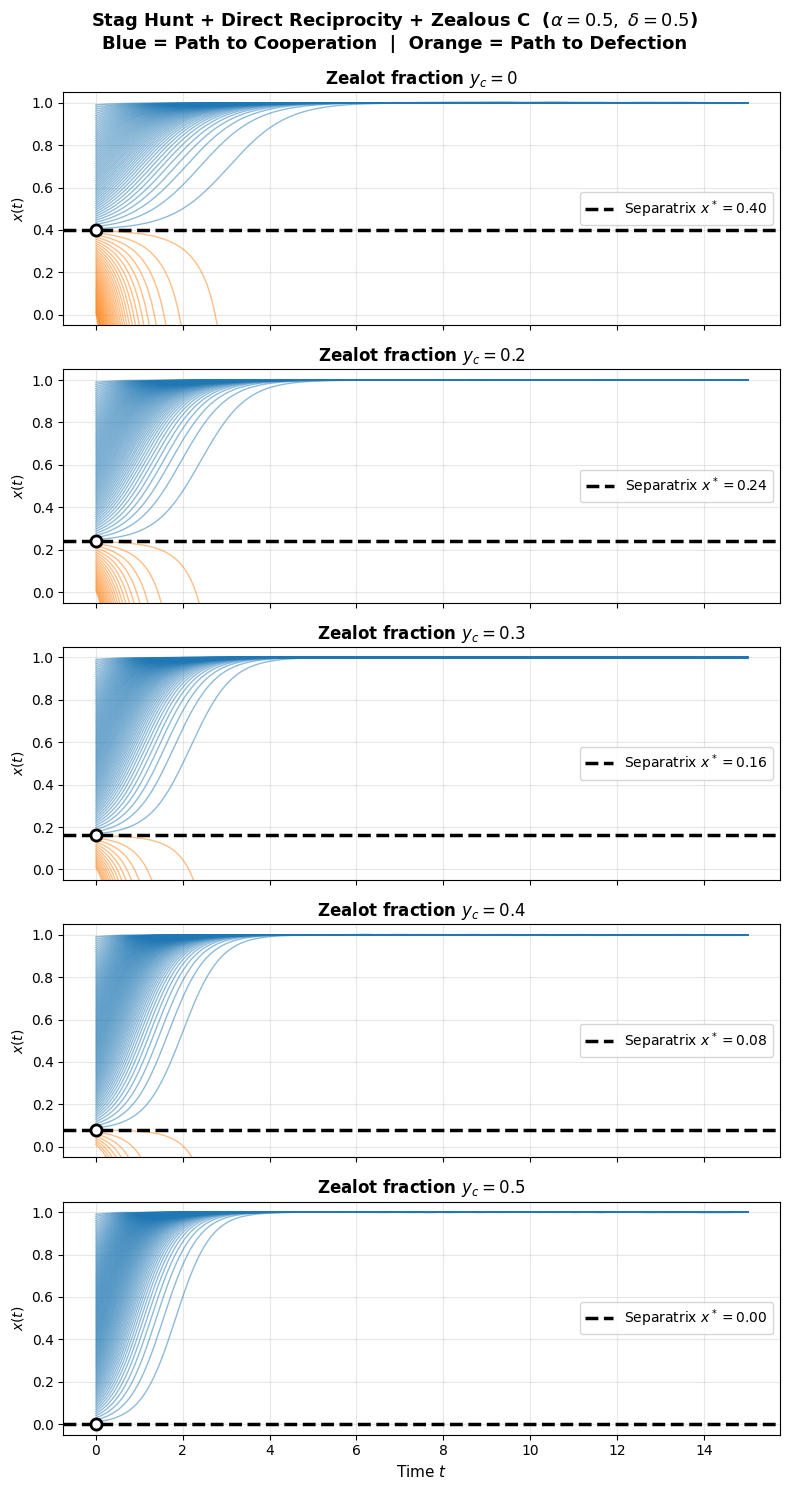

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
alpha = 0.5
delta = 0.5
R_tilde = 1.0 / (1.0 - alpha)  # 2.0
yc_vals = [0, 0.2, 0.3, 0.4, 0.5]
x0_vals = np.linspace(0.01, 0.99, 100)
t_span = (0, 15)
t_eval = np.linspace(0, 15, 200)

# Unnormalized smooth dynamics
def dxdt(t, x, yc):
    return (1.0 - x) * (2.5 * x + 2.0 * yc - 1.0)

fig, axes = plt.subplots(5, 1, figsize=(8, 15), sharex=True)

for ax, yc in zip(axes, yc_vals):
    x_star = 0.4 - 0.8 * yc
    
    for x_init in x0_vals:
        sol = solve_ivp(lambda t, x: dxdt(t, x, yc), 
                        t_span, [x_init], t_eval=t_eval, method='RK45')
        
        # Color based on final destination
        # Blue = Converged to Cooperation, Orange = Collapsed to Defection
        if sol.y[0][-1] > 0.5:
            color = '#1f77b4'  # High-contrast Blue
            alpha_val = 0.5
        else:
            color = '#ff7f0e'  # High-contrast Orange
            alpha_val = 0.5
            
        ax.plot(sol.t, sol.y[0], color=color, alpha=alpha_val, lw=1.0)
    
    # Plot the unstable threshold (separatrix)
    if x_star >= 0:
        ax.axhline(x_star, color='black', ls='--', lw=2.5, zorder=5,
                   label=f"Separatrix $x^* = {x_star:.2f}$")
        # Unstable point indicator
        ax.plot(0, x_star, 'ko', mfc='white', mew=2, ms=8, zorder=6)
    else:
        ax.text(0.5, 0.1, "Global Cooperation (No Separatrix)", 
                color='darkblue', fontsize=11, fontweight='bold', transform=ax.transAxes)
        
    ax.set_title(f"Zealot fraction $y_c = {yc}$", fontsize=12, fontweight='bold')
    ax.set_ylabel("$x(t)$")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center right', fontsize=10)

axes[-1].set_xlabel("Time $t$", fontsize=11)
plt.suptitle("Stag Hunt + Direct Reciprocity + Zealous C  ($\\alpha=0.5,\\ \\delta=0.5$)\n"
             "Blue = Path to Cooperation  |  Orange = Path to Defection",
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

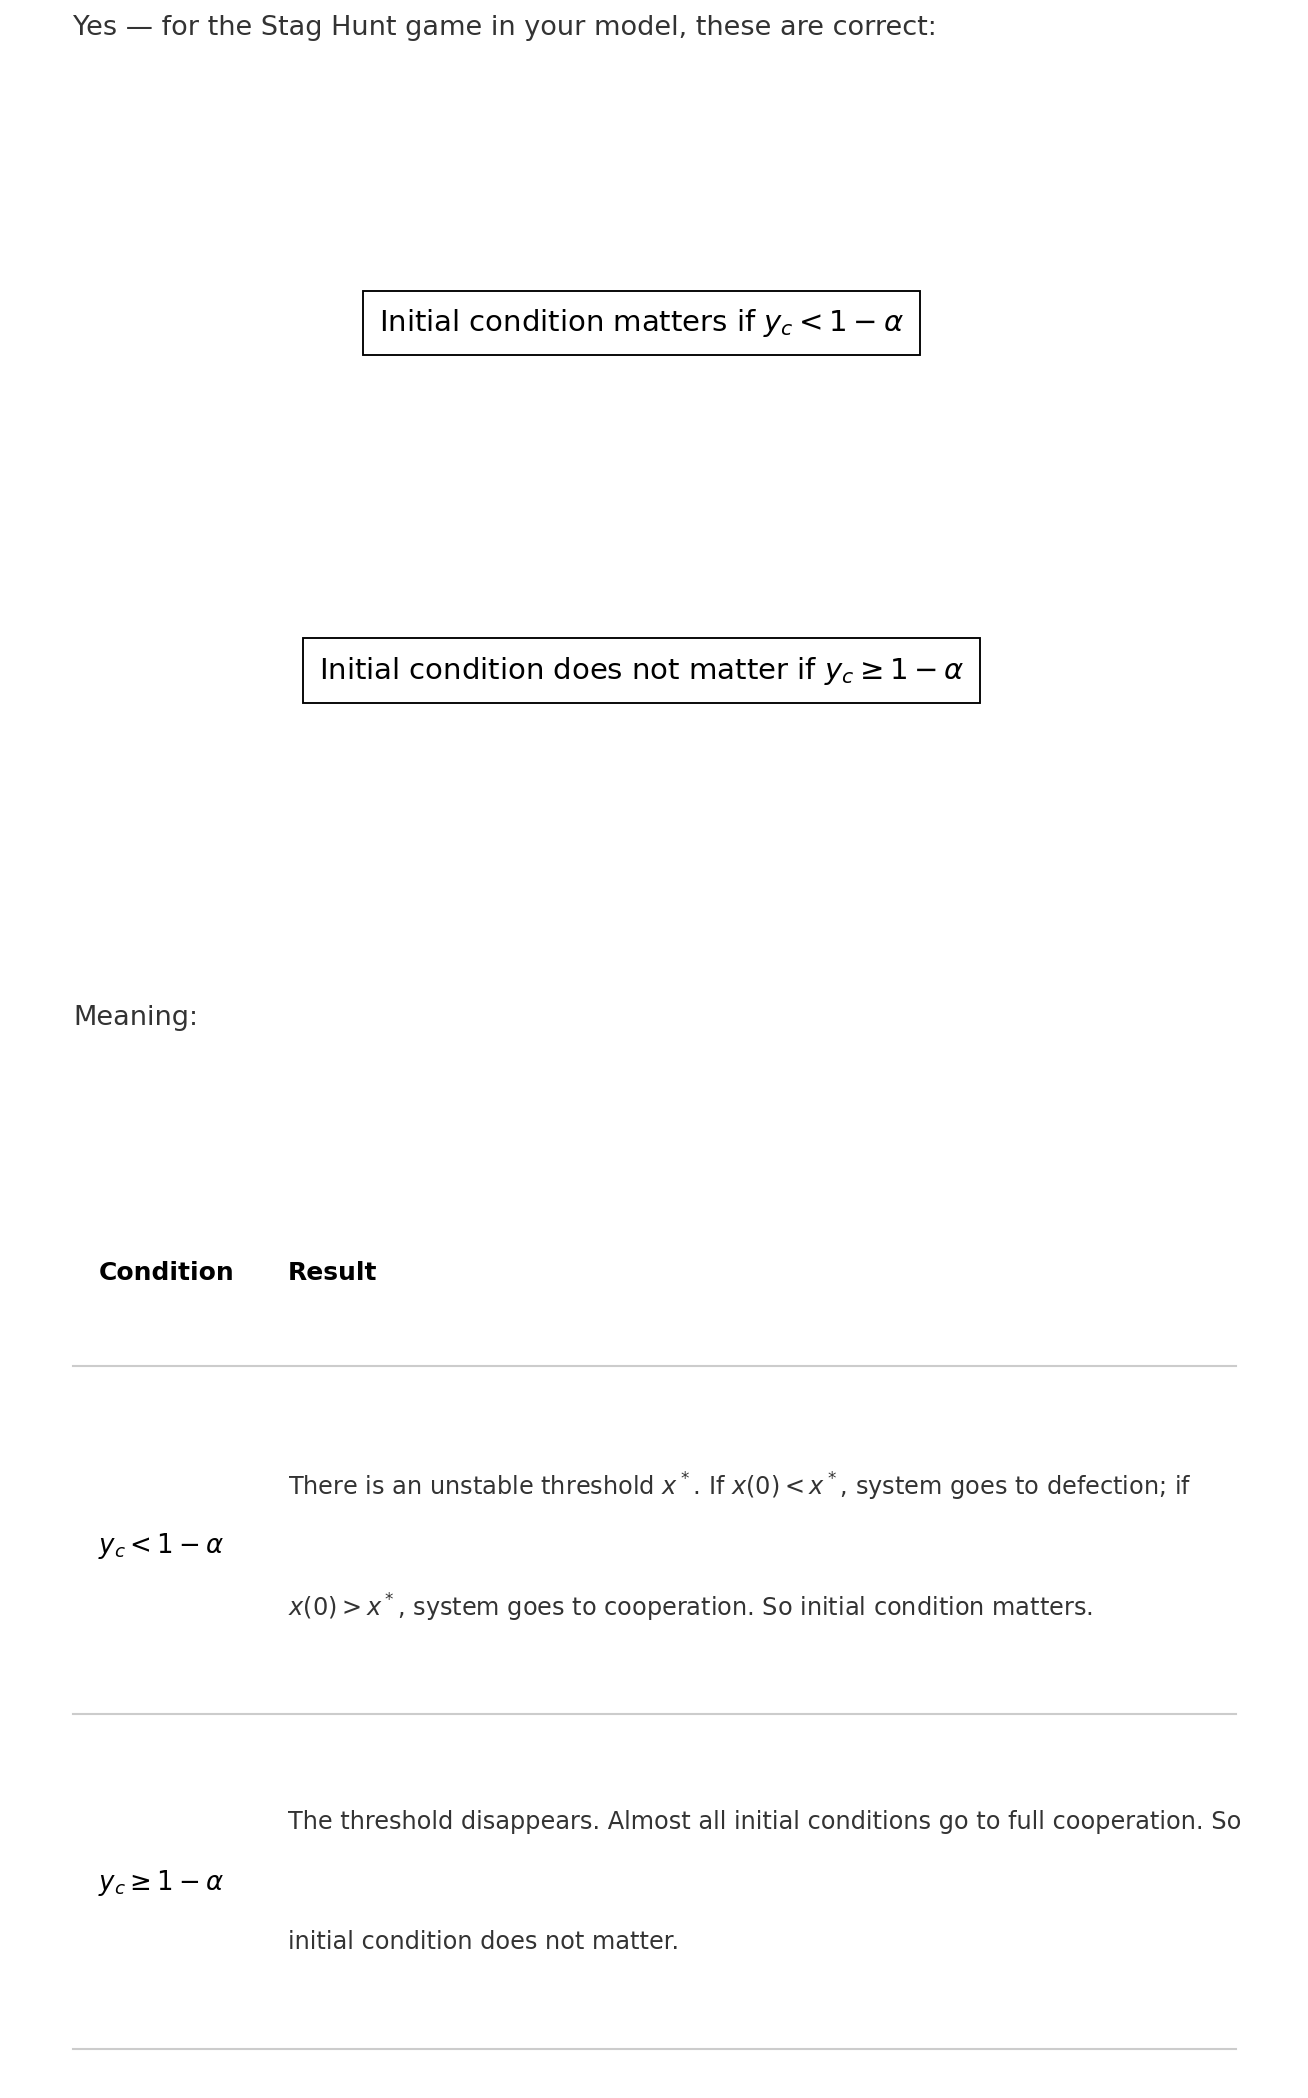

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150, facecolor='white')
ax.axis('off')

# ---------------- Top sentence ----------------
ax.text(0.05, 0.97, "Yes — for the Stag Hunt game in your model, these are correct:",
        fontsize=13, va='top', ha='left', color='#333333')

# ---------------- Boxed conditions ----------------
box = dict(boxstyle='square,pad=0.55', facecolor='none',
           edgecolor='black', linewidth=0.9)

ax.text(0.5, 0.855, r"Initial condition matters if $y_c < 1-\alpha$",
        fontsize=14, va='center', ha='center', bbox=box)

ax.text(0.5, 0.725, r"Initial condition does not matter if $y_c \geq 1-\alpha$",
        fontsize=14, va='center', ha='center', bbox=box)

# ---------------- "Meaning:" ----------------
ax.text(0.05, 0.60, "Meaning:", fontsize=13, va='top', ha='left', color='#333333')

# ---------------- Table geometry ----------------
x_c, x_r   = 0.07, 0.22          # column x-positions
x_l, x_rgt = 0.05, 0.97          # horizontal-rule span
rule       = dict(color='#cccccc', lw=1.0)
body_col   = '#333333'

# Header
ax.text(x_c, 0.500, "Condition", fontsize=12, fontweight='bold', va='center')
ax.text(x_r, 0.500, "Result",    fontsize=12, fontweight='bold', va='center')
ax.plot([x_l, x_rgt], [0.465, 0.465], **rule)

# Row 1
ax.text(x_c, 0.398, r"$y_c < 1-\alpha$", fontsize=12.5, va='center')
ax.text(x_r, 0.420, r"There is an unstable threshold $x^*$. If $x(0) < x^*$, "
                    r"system goes to defection; if",
        fontsize=11.5, va='center', color=body_col)
ax.text(x_r, 0.375, r"$x(0) > x^*$, system goes to cooperation. "
                    r"So initial condition matters.",
        fontsize=11.5, va='center', color=body_col)
ax.plot([x_l, x_rgt], [0.335, 0.335], **rule)

# Row 2
ax.text(x_c, 0.272, r"$y_c \geq 1-\alpha$", fontsize=12.5, va='center')
ax.text(x_r, 0.295, r"The threshold disappears. Almost all initial conditions go "
                    r"to full cooperation. So",
        fontsize=11.5, va='center', color=body_col)
ax.text(x_r, 0.250, r"initial condition does not matter.",
        fontsize=11.5, va='center', color=body_col)
ax.plot([x_l, x_rgt], [0.210, 0.210], **rule)

# ---------------- Save & show ----------------
plt.savefig("condition_table.png", dpi=250, bbox_inches='tight', facecolor='white')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30880\2898993338.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


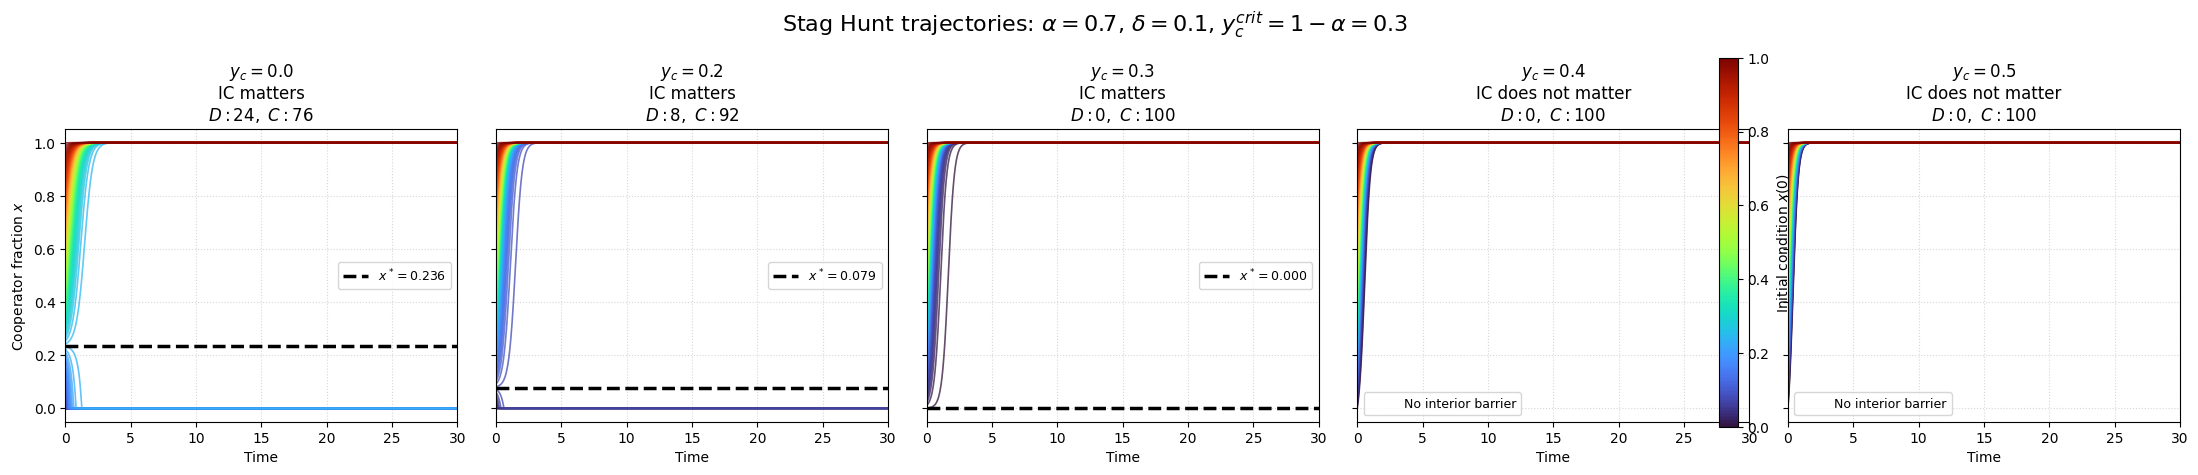

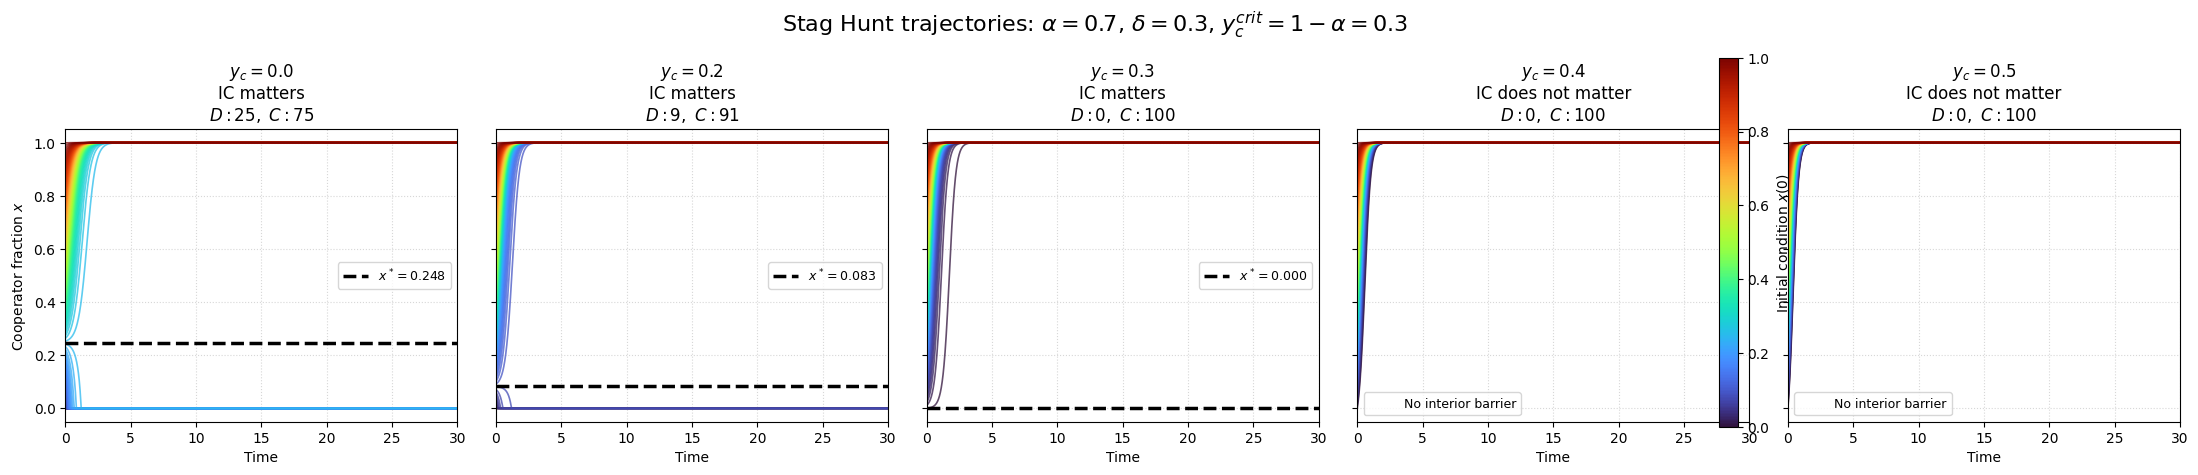

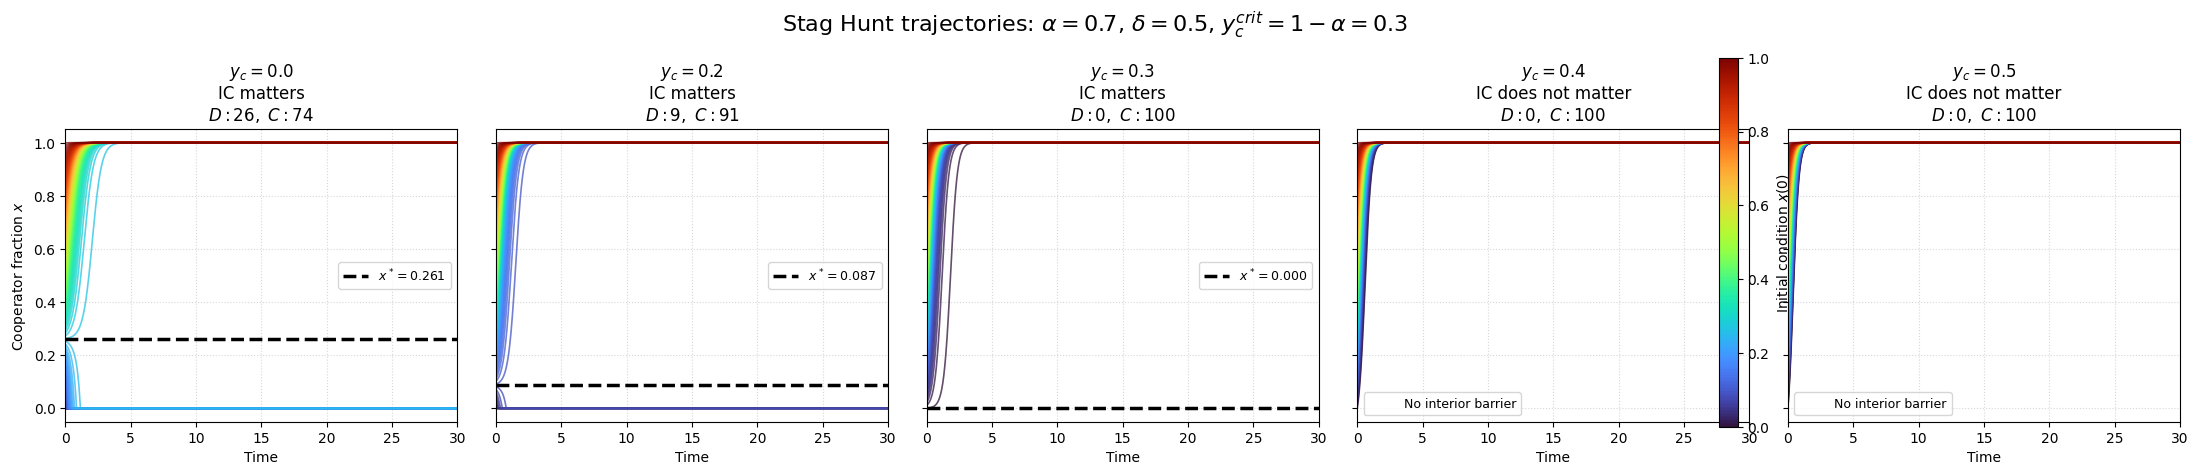

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# Stag Hunt + Direct Reciprocity + Zealous Cooperators
# Testing different delta values
# ============================================================

# Fixed alpha
alpha = 0.7

# Critical zealot fraction
yc_crit = 1 - alpha

# Different delta values
delta_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Zealot values
yc_values = [0.0, 0.2, 0.3, 0.4, 0.5]

# 100 initial conditions
x0_values = np.linspace(0.001, 0.999, 100)

# Time
T = 30
n_steps = 3000
t = np.linspace(0, T, n_steps)
dt = t[1] - t[0]

# Effective R payoff
R_eff = 1 / (1 - alpha)

# Color settings
cmap = plt.colormaps["turbo"]
norm = Normalize(vmin=0, vmax=1)


# ============================================================
# Dynamics: unnormalized form
# dx/dt = (1-x)[ R_eff(x+yc) - 1 + x(1-delta) ]
# ============================================================

def f(x, yc, delta):
    return (1 - x) * (R_eff * (x + yc) - 1 + x * (1 - delta))


def barrier(yc, delta):
    """
    Unstable interior equilibrium:
    x* = (1 - R_eff*yc) / (R_eff + 1 - delta)
    """
    return (1 - R_eff * yc) / (R_eff + 1 - delta)


# ============================================================
# Plot: one separate figure for each delta
# ============================================================

for delta in delta_values:

    fig, axes = plt.subplots(
        1, len(yc_values),
        figsize=(22, 4.8),
        sharex=True,
        sharey=True
    )

    fig.suptitle(
        fr"Stag Hunt trajectories: $\alpha={alpha}$, $\delta={delta}$, "
        fr"$y_c^{{crit}}=1-\alpha={yc_crit:.1f}$",
        fontsize=16
    )

    for j, yc in enumerate(yc_values):

        ax = axes[j]

        # Store final states for checking
        final_states = []

        for x0 in x0_values:

            x = np.zeros(len(t))
            x[0] = x0

            for k in range(len(t) - 1):
                x[k+1] = x[k] + dt * f(x[k], yc, delta)
                x[k+1] = np.clip(x[k+1], 0, 1)

            final_states.append(x[-1])

            ax.plot(
                t,
                x,
                color=cmap(norm(x0)),
                linewidth=1.2,
                alpha=0.75
            )

        final_states = np.array(final_states)

        # Count outcomes
        n_defect = np.sum(final_states < 0.05)
        n_coop = np.sum(final_states > 0.95)

        # Barrier
        x_star = barrier(yc, delta)

        if 0 < x_star < 1:
            ax.axhline(
                x_star,
                color="black",
                linestyle="--",
                linewidth=2.5,
                label=fr"$x^*={x_star:.3f}$"
            )
            condition_text = "IC matters"
        else:
            ax.plot([], [], " ", label="No interior barrier")
            condition_text = "IC does not matter"

        ax.set_title(
            fr"$y_c={yc}$" + "\n" +
            condition_text + "\n" +
            fr"$D:{n_defect},\ C:{n_coop}$",
            fontsize=12
        )

        ax.set_xlabel("Time")
        ax.set_xlim(0, T)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(fontsize=9)

        if j == 0:
            ax.set_ylabel("Cooperator fraction $x$")

    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label("Initial condition $x(0)$")

    plt.tight_layout()
    plt.show()